In [126]:
import glob
import os
import pandas as pd
import numpy as np
import re

In [127]:
def is_header_row(row) -> bool:
    return any(
        str(cell).strip().lower() in ['nombre', 'posición', 'pos']
        for cell in row
    )

def is_section_title(row) -> bool:
    pattern = re.compile(r"(catchers|pitchers|infielders|outfielders)", re.IGNORECASE)
    return any(pattern.fullmatch(str(cell).strip()) for cell in row)

def extract_table_sections_from_excel(filepath: str, preview_rows: int = 5) -> List[pd.DataFrame]:
    cols = ['id','raw_name','position']
    df_raw = pd.read_excel(filepath, header=None)
    start_rows = []
    title_rows = []

    for i in range(len(df_raw)):
        row = df_raw.iloc[i]
        if is_header_row(row) or is_section_title(row):
            title = next((str(cell).strip().lower() for cell in row if str(cell).strip().lower() in ['catchers', 'pitchers', 'infielders', 'outfielders']), None)
            start_rows.append(i)
            title_rows.append(title)

    tables = []
    for idx, start in enumerate(start_rows):
        end = start_rows[idx + 1] if idx + 1 < len(start_rows) else None
        section = df_raw.iloc[start:end]
        section.columns = section.iloc[0]
        section = section[1:]  # remove header row
        section.dropna(axis=1,how='all',inplace=True)
        section.dropna(axis=0,how='all',inplace=True)
        if len(section.columns):
            section.columns = [cols[i] if i < 3 else 'other' for i in range(len(section.columns)) ]
            section = section[['id', 'raw_name', 'position']]
        section = section.reset_index(drop=True)
        section['title'] = title_rows[idx]
        tables.append(section.head(preview_rows))

    return tables

In [205]:
import pdfplumber

def extract_pdf_tables_with_titles(pdf_path: str) -> pd.DataFrame:
    section_titles = ['CATCHER', 'INFIELD', 'OUTFIELD', 'PITCHER']
    title = None
    rows = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text().split('\n')
            for line in text:
                for t in section_titles:
                    if t in line.upper():
                        title = t.capitalize()

            tables = page.extract_tables(table_settings={"vertical_strategy": "text", 
                                               "horizontal_strategy": "lines", 
                                               "snap_tolerance": 1,})
            df_temp = pd.DataFrame(tables).T
            df_temp = df_temp.iloc[2:]
            # for table in tables:
            #     for row in table:
            #         if not row or len(row) < 4:
            #             continue
            #         id_candidate = row[0].strip() if row[0] else ""
            #         name_candidate = row[1].strip() if len(row) > 1 and row[1] else ""
            #         pos_candidate = row[2].strip() if len(row) > 2 and row[2] else ""

            #         if id_candidate.isdigit() and name_candidate:
            #             rows.append({
            #                 'id': id_candidate,
            #                 'raw_name': name_candidate,
            #                 'position': pos_candidate,
            #                 'title': title
            #             })

    return df_temp

In [206]:
def extract_and_preview_documents(zip_path: str, extract_to: str = "temp_docs") -> dict:
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    content = {}
    for filename in os.listdir(extract_to):
        filepath = os.path.join(extract_to, filename)

        # if filename.lower().endswith(('.xlsx', '.xls')):
        #     try:
        #         tables = extract_table_sections_from_excel(filepath)
        #         content[filename] = tables
        #     except Exception as e:
        #         content[filename] = [f"Error al leer Excel: {e}"]

        if filename.lower().endswith('.pdf'):
            #try:
                text_preview = extract_pdf_tables_with_titles(filepath)
                text_preview.dropna(inplace=True)
                content[filename] = [text_preview]
            #except Exception as e:
            #    content[filename] = [f"Error al leer PDF: {e}"]

        #else:
        #    content[filename] = ["Tipo de archivo no soportado"]
    return content

In [207]:
preview = extract_and_preview_documents("roosters.zip")

for filename, sections in preview.items():
    print(f"--- {filename} ---")
    for i, section in enumerate(sections):
        print(f"[Sección {i+1}]")
        print(section)
        print("\n")
    print("\n" + "-"*80 + "\n")

--- ROSTER DUR 10-JULIO-2025.pdf ---
[Sección 1]
                                                    0
2   [1 GER\n2 CARL, ALDI DIAZ, 27, NO, NAC, D/Z, 1...
3   [None, OS GARZON, 14, , D, /D, 95, 1.85, 14-Ma...
4   [3 ALEJAN, DRO URIAS*, 4, N, OV D, /D, 92, 1.7...
5                      [, , , , , , INFIE, LDERS, , ]
6   [4 CJ H\n5 DREW\n6 DAVI, INOJOSA, 76, , D, /D,...
7   [None, LUGBAUER, 17, NO, NAC D, /Z, 99, 1.93, ...
8   [None, D HENSLEY, 8, NO, NAC D, /D, 99, 1.98, ...
9   [7 ARMAN\n8 MANU, DO ALVAREZ, 78, NO, NAC D, /...
10  [None, EL ORDUÑO, 53, , D, /D, 83, 178, 21-Jan...
11  [9 RUB, EN TEJADA, 28, NO, NAC D, /D, 90, 1.80...
12  [10 VICTO, R MARQUEZ, 16, , D, /A, 70, 1.72, 2...
13                    [, , , , , , OUTFI, ELDERS, , ]
14  [11 RICK, Y ALVAREZ, 91, , D, /D, 80, 1.80, 7-...
15  [12 ALON\n13 ALA\n14 SABRIE\n15 ISMAEL, SO GAI...
16  [None, N ALONSO, 49, NO, NAC D, /D, 90, 1.88, ...
17  [None, L POLANCO, 51, NO, NAC D, /D, 81, 1.8, ...
18  [None, ALCANTARA *, 9, NO, NA

## Debug pdf extract

In [208]:
extract_to = 'temp_docs'
content = {}
for filename in os.listdir(extract_to):
    filepath = os.path.join(extract_to, filename)
    print(filepath)

temp_docs\ROSTER CHI 10-JULIO-2025.xlsx
temp_docs\ROSTER DUR 10-JULIO-2025.pdf
temp_docs\ROSTER LAG 10-JULIO-2025.xlsx
temp_docs\ROSTER MTY 10-JULIO-2025.pdf
temp_docs\ROSTER MVA 10-JULIO-2025.xlsx
temp_docs\ROSTER PUE 10-JULIO-2025.xlsx
temp_docs\ROSTER VER 10-JULIO-2025.pdf


In [285]:
p0.

580

In [373]:
pdf = pdfplumber.open("temp_docs\ROSTER DUR 10-JULIO-2025.pdf")
p0 = pdf.pages[0]
p0 = p0.within_bbox((40, 90, p0.width-260, p0.height))

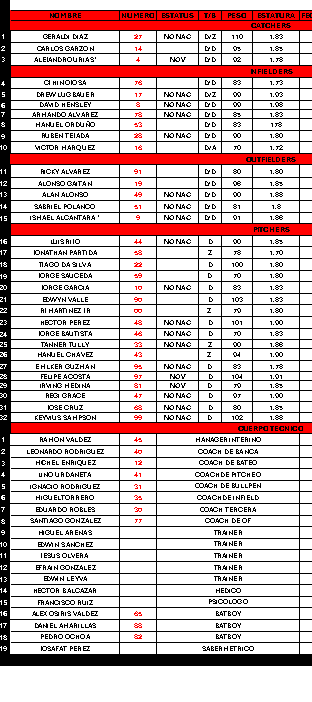

In [374]:
im = p0.to_image()
im

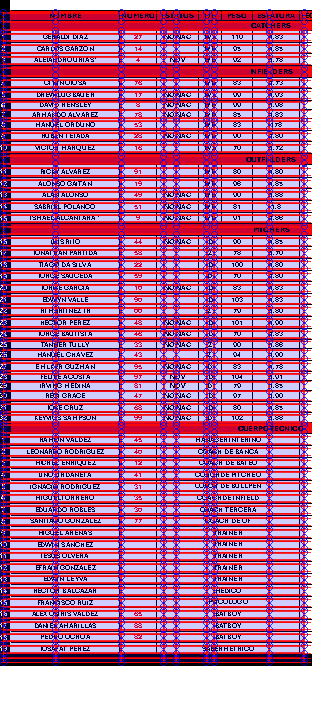

In [375]:
im.debug_tablefinder(table_settings={"vertical_strategy":"text",
                                    "horizontal_strategy":"text"})

In [416]:
table = p0.extract_table(table_settings={"vertical_strategy":"text",
                                    "horizontal_strategy":"text"})

idx_vals = []
raw_names = []

def unir_nombres(lista):
    nombres_limpios = []
    for linea in lista:
        # Quitar número inicial (puede ser más de un dígito)
        linea_sin_num = re.sub(r'^\d+\s+', '', linea.strip())
        # Unir fragmentos separados indebidamente
        nombre_unido = ' '.join(linea_sin_num.split())
        nombres_limpios.append(nombre_unido)
    return nombres_limpios

for idx, row in enumerate(table):
    if idx >0:
        if all(cell == '' for cell in row):
            pass
        elif 'TECNICO' in row:
            break
        else:
            if row.count('') > 4:
                position = "".join(row[-2:])
            else:
                val1 = row[0]
                idx = val1[0]
                idx_vals.append(idx)
                raw_name = unir_nombres(row[:2])
                print(raw_name)
            
idx_vals
    

['GER', 'ALDI DIAZ']
['CARL', 'OS GARZON']
['ALEJAN', 'DRO URIAS*']
['CJ H', 'INOJOSA']
['DREW', 'LUGBAUER']
['DAVI', 'D HENSLEY']
['ARMAN', 'DO ALVAREZ']
['MANU', 'EL ORDUÑO']
['RUB', 'EN TEJADA']
['VICTO', 'R MARQUEZ']
['RICK', 'Y ALVAREZ']
['ALON', 'SO GAITAN']
['ALA', 'N ALONSO']
['SABRIE', 'L POLANCO']
['ISMAEL', 'ALCANTARA *']
['L', 'UIS RIJO']
['JONAT', 'HAN PARTIDA']
['TIAG', 'O DA SILVA']
['JORG', 'E SAUCEDA']
['JOR', 'GE GARCIA']
['EDW', 'YN VALLE']
['RJ M', 'ARTINEZ JR']
['HEC', 'TOR PEREZ']
['JORG', 'E BAUTISTA']
['TAN', 'NER TULLY']
['MANU', 'EL CHAVEZ']
['EMILK', 'ER GUZMAN']
['FELIP', 'E ACOSTA']
['IRVIN', 'G MEDINA']
['RE', 'GI GRACE']
['JO', 'SE CRUZ']
['KEYVIU', 'S SAMPSON']


['1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '0',
 '1',
 '2']